# 04. Advanced Model: Balanced Random Forest Classifier
**Author**: Yordanos Andargachew (Phone: `+251 952 190 305`)  
**Project**: Bank Loan Risk Prediction System  

---

## 1. Ensemble Architecture & Non-Linear Risk Modeling
Random Forest is an ensemble learning method combining bagging (bootstrap aggregating) and random feature subspace selection across $B=100$ decorrelated decision trees:
$$\hat{f}_{RF}(x) = \frac{1}{B} \sum_{b=1}^B T_b(x)$$

Unlike linear models, Random Forest captures complex non-linear credit threshold interactions (such as high loan amount combined with young age and short employment duration).

In [1]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("."))

from src.preprocessor import CreditDataPreprocessor

# Load dataset
data_path = os.path.join("..", "data", "dataset.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("data", "dataset.csv")

df = pd.read_csv(data_path)
X = df.drop(columns=['Risk'])
y = CreditDataPreprocessor.encode_target(df['Risk'])

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Load preprocessor
models_dir = os.path.join("..", "models")
if not os.path.exists(models_dir):
    models_dir = "models"

preprocessor = CreditDataPreprocessor.load(os.path.join(models_dir, "preprocessor.pkl"))
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print(f"X_train_trans shape: {X_train_trans.shape}")
print(f"X_test_trans shape:  {X_test_trans.shape}")

X_train_trans shape: (800, 26)
X_test_trans shape:  (200, 26)


## 2. Advanced Model Training: Random Forest Classifier

In [2]:
# Initialize Balanced Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_trans, y_train)
print("Random Forest Classifier Trained Successfully!")

Random Forest Classifier Trained Successfully!


## 3. Evaluation on 20% Holdout Test Split

In [3]:
y_pred = rf_model.predict(X_test_trans)
y_proba = rf_model.predict_proba(X_test_trans)[:, 1]

# Compute metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Random Forest Test Metrics ===")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall:    {rec:.4f} ({rec*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Good Risk (0)', 'Bad Risk (1)']))

=== Random Forest Test Metrics ===
Accuracy:  0.7000 (70.00%)
Precision: 0.5000 (50.00%)
Recall:    0.7167 (71.67%)
F1-Score:  0.5890
ROC-AUC:   0.7844

Classification Report:
               precision    recall  f1-score   support

Good Risk (0)       0.85      0.69      0.76       140
 Bad Risk (1)       0.50      0.72      0.59        60

     accuracy                           0.70       200
    macro avg       0.68      0.70      0.68       200
 weighted avg       0.75      0.70      0.71       200



## 4. Confusion Matrix & ROC Curve

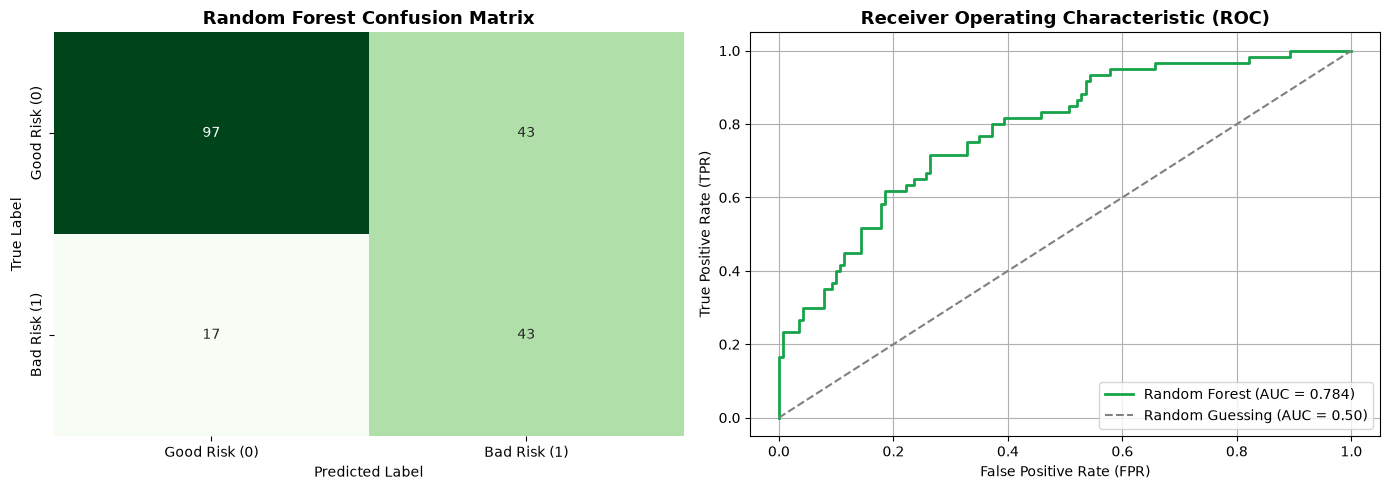

In [4]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Good Risk (0)', 'Bad Risk (1)'],
            yticklabels=['Good Risk (0)', 'Bad Risk (1)'], cbar=False)
axes[0].set_title("Random Forest Confusion Matrix", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#16a34a', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing (AUC = 0.50)')
axes[1].set_title("Receiver Operating Characteristic (ROC)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("False Positive Rate (FPR)")
axes[1].set_ylabel("True Positive Rate (TPR)")
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Feature Importance Analysis (MDI / Gini Impurity)

Top 10 Most Important Features:
                  Feature  Importance
            Credit amount    0.176833
                 Duration    0.151779
 Checking account_unknown    0.138020
                      Age    0.121521
  Checking account_little    0.058817
                      Job    0.039593
   Saving accounts_little    0.034735
  Saving accounts_unknown    0.031022
Checking account_moderate    0.028932
         Purpose_radio/TV    0.023365


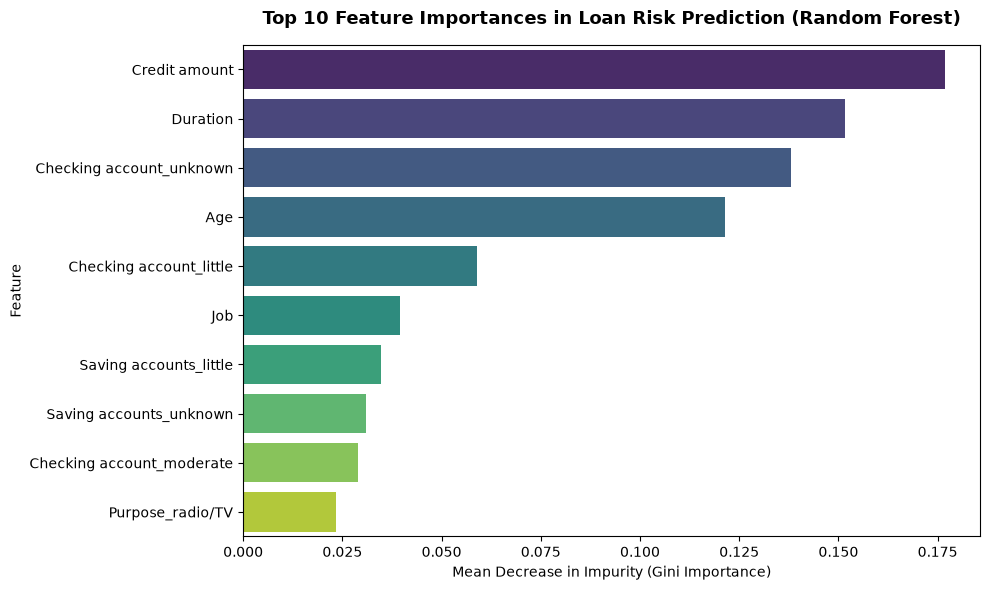

In [5]:
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feat_imp_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("Top 10 Feature Importances in Loan Risk Prediction (Random Forest)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Mean Decrease in Impurity (Gini Importance)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 6. Saving Model Artifact

In [6]:
rf_artifact_path = os.path.join(models_dir, "random_forest.pkl")
joblib.dump(rf_model, rf_artifact_path)
print(f"Successfully saved Random Forest model to '{rf_artifact_path}'!")

Successfully saved Random Forest model to '../models/random_forest.pkl'!
